##Bibliotecas utilizadas

In [1]:
import sys
import numpy as np
import scipy
import cv2
import sklearn
import skimage
import tensorflow as tf
import matplotlib

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("OpenCV:", cv2.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Scikit-image:", skimage.__version__)
print("TensorFlow:", tf.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.1
SciPy: 1.18.0
OpenCV: 5.0.0
Scikit-learn: 1.9.0
Scikit-image: 0.26.0
TensorFlow: 2.21.0
Matplotlib: 3.11.1


In [2]:
from scipy.io import loadmat
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import metrics as metrics
import tensorflow as tf
from tensorflow.keras import backend as K
from keras import layers, Input, Model
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, UpSampling2D

##Conjunto de dados

Acessibilidade (montagem) ao Google Drive do usuário para acessar o conjunto de dados

Obtenção dos dados (2780 imagens térmicas infravermelhas) compactadas no formato matfile (Matlab)

In [3]:
from pathlib import Path
from scipy.io import loadmat

DATASET_DIR = Path("../dataset")

mat_front = loadmat(
    DATASET_DIR / "COMP412-6_Front_Flash-000136.mat"
)

mat_back = loadmat(
    DATASET_DIR / "COMP412-6_Back_Flash-000137.mat"
)

Manipulação dos dados obtidos pelo arquivo matfile, selecionando somente as matrizes que representam cada uma das imagens (dados) do conjunto de dados

In [4]:
dataset_front = mat_front['temperature']
dataset_back = mat_back['temperature']

print(dataset_front.shape)
print(dataset_back.shape)
print(dataset_front.dtype)
print(dataset_back.dtype)

(416, 421, 1385)
(423, 419, 1395)
float32
float32


In [5]:
print(dataset_front.shape)
print(dataset_back.shape)

(416, 421, 1385)
(423, 419, 1395)


Transposição da matriz de dados para adequação e manipulação com as bibliotecas numéricas do python

In [6]:
dataset_front = np.moveaxis(dataset_front, 2, 0)
dataset_back = np.moveaxis(dataset_back, 2, 0)

In [7]:
print(dataset_front.shape)
print(dataset_back.shape)

(1385, 416, 421)
(1395, 423, 419)


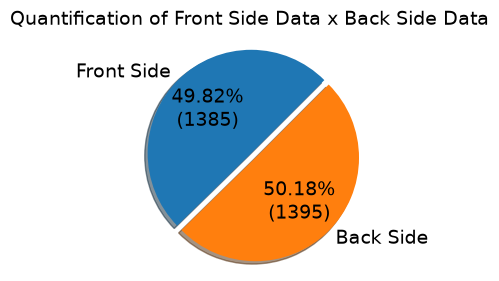

np.int64(2780)

In [8]:
def format(percent_value):
  return '{:.2f}%\n({:.0f})'.format(percent_value, pie_data.sum() * (percent_value / 100))

pie_data = np.array([len(dataset_front), len(dataset_back)])
pie_labels = ['Front Side', 'Back Side']
explode = [0.03 for x in pie_data]
fig, ax = plt.subplots()
ax.pie(pie_data, labels = pie_labels, explode = explode, autopct = format, shadow = True, startangle = 45, textprops = {'fontsize': 14})
fig.suptitle('Quantification of Front Side Data x Back Side Data', fontsize = 14)
ax.axis('equal')
fig.set_figheight(3)
fig.set_figwidth(3)
plt.show()
pie_data.sum()

Unificação das duas bases originais de dados

In [9]:
dataset = list(dataset_front) + list(dataset_back)

In [10]:
train_images, temp_images = train_test_split(
    dataset,
    train_size=0.8,
    random_state=0
)

valid_images, test_images = train_test_split(
    temp_images,
    test_size=0.5,
    random_state=0
)

Normalização dos dados

In [11]:
global_min = min(
    np.min(image)
    for image in train_images
)

global_max = max(
    np.max(image)
    for image in train_images
)

In [12]:
def normalizar_inplace(imagens, global_min, global_max):
    intervalo = np.float32(global_max - global_min)
    minimo = np.float32(global_min)

    for image in imagens:
        image -= minimo
        image /= intervalo

    return imagens


train_images = normalizar_inplace(
    train_images,
    global_min,
    global_max
)

valid_images = normalizar_inplace(
    valid_images,
    global_min,
    global_max
)

test_images = normalizar_inplace(
    test_images,
    global_min,
    global_max
)

In [13]:
print(
    "train:",
    min(np.min(img) for img in train_images),
    max(np.max(img) for img in train_images)
)

print(
    "valid:",
    min(np.min(img) for img in valid_images),
    max(np.max(img) for img in valid_images)
)

print(
    "test:",
    min(np.min(img) for img in test_images),
    max(np.max(img) for img in test_images)
)

train: 0.0 1.0
valid: 0.0055172592 0.39796573
test: 0.0028950218 0.22301514


In [14]:
def extrair_patches(
    imagens,
    patch_size=128,
    stride=128
):
    patches = []

    for image in imagens:
        altura, largura = image.shape

        for y in range(
            0,
            altura - patch_size + 1,
            stride
        ):
            for x in range(
                0,
                largura - patch_size + 1,
                stride
            ):
                patch = image[
                    y:y + patch_size,
                    x:x + patch_size
                ]

                patches.append(patch)

    return np.array(
        patches,
        dtype=np.float32
    )

In [15]:
patch_size = 128
stride = 128

x_train = extrair_patches(
    train_images,
    patch_size,
    stride
)

x_valid = extrair_patches(
    valid_images,
    patch_size,
    stride
)

x_test = extrair_patches(
    test_images,
    patch_size,
    stride
)

In [16]:
print("x_train:", x_train.shape, x_train.dtype)
print("x_valid:", x_valid.shape, x_valid.dtype)
print("x_test:", x_test.shape, x_test.dtype)

print("\nIntervalos:")
print("train:", np.min(x_train), np.max(x_train))
print("valid:", np.min(x_valid), np.max(x_valid))
print("test :", np.min(x_test), np.max(x_test))

x_train: (20016, 128, 128) float32
x_valid: (2502, 128, 128) float32
x_test: (2502, 128, 128) float32

Intervalos:
train: 0.0018435591 1.0
valid: 0.006824956 0.39796573
test : 0.004993554 0.22301514


Transformando o tipo do conjunto de dados de "python list" para o formato "ndarray (float32)" da biblioteca numpy (utilizado pelo Kernas - biblioteca Google para machine learning)

Divisão por imagem original:

In [17]:
x_train = np.expand_dims(x_train, axis=-1)
x_valid = np.expand_dims(x_valid, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

x_train: (20016, 128, 128, 1)
x_valid: (2502, 128, 128, 1)
x_test: (2502, 128, 128, 1)


In [18]:
assert x_train.ndim == 4
assert x_valid.ndim == 4
assert x_test.ndim == 4

assert x_train.shape[-1] == 1
assert x_valid.shape[-1] == 1
assert x_test.shape[-1] == 1

Embaralhamento do conjunto de dados

Aplicação de ruído gaussiano nos subconjuntos de treino, validação e teste

In [19]:
sigma = 0.005

In [20]:
noise_train = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=x_train.shape
).astype(np.float32)

noise_valid = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=x_valid.shape
).astype(np.float32)

noise_test = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=x_test.shape
).astype(np.float32)

x_train_noisy = np.clip(
    x_train + noise_train,
    0.0,
    1.0
).astype(np.float32)

x_valid_noisy = np.clip(
    x_valid + noise_valid,
    0.0,
    1.0
).astype(np.float32)

x_test_noisy = np.clip(
    x_test + noise_test,
    0.0,
    1.0
).astype(np.float32)

##Apresentação das Imagens

Exibição das 10 primeiras imagens dos seguintes conjuntos dos dados de testes:

* Original;
* Com ruído gaussiano.

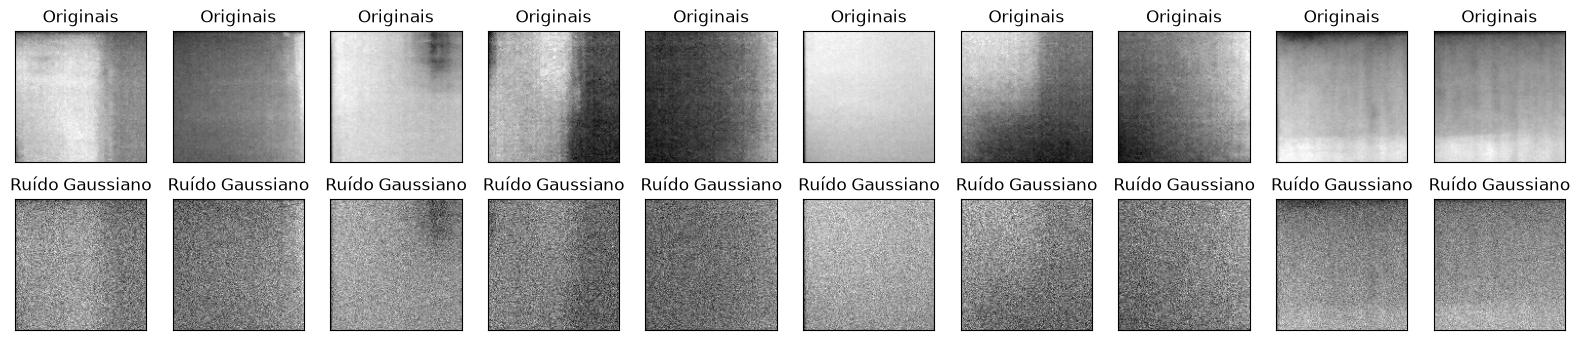

In [21]:
n = 10

plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    ax = plt.subplot(2, n, i)
    plt.title('Originais')
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + n)
    plt.title('Ruído Gaussiano')
    plt.imshow(x_test_noisy[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

##Implementação da Arquitetura do Autoencorder CNN

AutoEncoder (AE) é um tipo de Rede Neural de Aprendizagem Profunda (*Deep Learning Neural Network* - DLNN ou *Deep Neural Network* - DNN), na qual seu aprendizado é não supervisionado e sua arquitetura é fundamentada nas Redes Neurais Convolucionais (*Convolutional Neural Network* - CNN).

Essencialmente os autoencoders são segregados em três módulos principais: o Encoder, o Code, e o Decoder.

O AE's têm como objetivo aproximar a saída aos dados da entrada. Ou seja, quanto mais a saída se assemelhar com a entrada, melhor é a capacidade de reconstrução do autoencoder. Entretanto, assim como diversas outras redes, há que se atentar a questões como Overfitting.

A Figura 1 representa, diagramaticamente, a estrutura do AE e seus três pilares básicos: o Encoder, o Code e Decoder.

<figure>
<center>
<figcaption>Figura 1: visão geral da estrutura do AutoEnconder
</figcaption>
<img src='https://miro.medium.com/v2/resize:fit:720/format:webp/1*Me8UpTdSuznquyF86s9xeQ.jpeg' />
<figcaption>Fonte: https://miro.medium.com/v2/resize:fit:720/format:webp/1*Me8UpTdSuznquyF86s9xeQ.jpeg
</figcaption>
</center>
</figure>

Naturalmente não há motivos que justifique o interesse em uma rede neural que apresente, em sua saída, as suas entradas.
Porém, o aspecto de grande relevância nos AE's é a codificação dos dados da entrada pelo Encoder, ou seja, o Code.
A figura 2 ilustra um diagrama um pouco mais aprofundado e detalhado sobre a arquitetura dos AE's.

<figure>
<center>
<figcaption>Figura 2: modelo de arquitetura do AutoEnconder
</figcaption>
<img src='https://lilianweng.github.io/posts/2018-08-12-vae/denoising-autoencoder-architecture.png' />
<figcaption>Fonte: https://lilianweng.github.io/posts/2018-08-12-vae/denoising-autoencoder-architecture.png
</figcaption>
</center>
</figure>

Fontes:

* https://www.deeplearningbook.org/contents/autoencoders.html


Criação das camadas de convolucão e pooling (típicas de uma CNN clássica) com kernels 3x3, funções de ativação do tipo ReLU (Unidade Linear Retificada), mantendo as mesmas dimensões dos dados da entrada

In [22]:
inputs = tf.keras.Input(shape=(None, None, 1))

x = tf.keras.layers.Conv2D(
    64,
    3,
    padding="same",
    activation="relu"
)(inputs)

for _ in range(5):
    x = tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

predicted_noise = tf.keras.layers.Conv2D(
    1,
    3,
    padding="same",
    activation="linear",
    name="predicted_noise"
)(x)

restored = tf.keras.layers.Subtract(
    name="restored_image"
)([inputs, predicted_noise])

model = tf.keras.Model(
    inputs=inputs,
    outputs=restored
)

Sumário do Denoising AutoEncoder

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        640 │ input_layer[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │     36,928 │ conv2d[0][0]      │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_1[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_2[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_3[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_4[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predicted_noise     │ (None, None,      │        577 │ conv2d_5[0][0]    │
│ (Conv2D)            │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ restored_image      │ (None, None,      │          0 │ input_layer[0][0… │
│ (Subtract)          │ None, 1)          │            │ predicted_noise[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 185,857 (726.00 KB)

 Trainable params: 185,857 (726.00 KB)

 Non-trainable params: 0 (0.00 B)

Compilação da CNN (AE) com a função ADAM para a otimização e a função Binary Cross-Entropy

In [24]:
def mae_ssim_loss(y_true, y_pred):

    mae = tf.reduce_mean(
        tf.abs(y_true - y_pred)
    )

    ssim = tf.reduce_mean(
        tf.image.ssim(
            y_true,
            y_pred,
            max_val=1.0
        )
    )

    structural_loss = 1.0 - ssim

    return (
        0.8 * mae +
        0.2 * structural_loss
    )

In [25]:
model.compile(
    optimizer='adam',
    loss=mae_ssim_loss
)

Etapa de treinamento da CNN-AE utilizando os dados de treino e de testes, originais e com sintéticos ruídos gaussianos, 50 épocas, lotes (subgrupos) de tamanho 128 e que, a cada lote, os dados serão selecionados de forma aleatória e com reposição

## Recuperação do Experimento 05 após interrupção

Esta versão **não reinicia o treinamento**. Ela carrega o melhor modelo persistido em `melhor_modelo_exp05.keras` e segue diretamente para inferência, métricas e visualização.

O backup em `backup_treinamento_exp05/` é preservado e não é alterado por este notebook.


In [26]:
from pathlib import Path

MODEL_PATH = Path("melhor_modelo_exp05.keras")
BACKUP_DIR = Path("backup_treinamento_exp05")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modelo não encontrado: {MODEL_PATH.resolve()}"
    )

print(f"Modelo encontrado: {MODEL_PATH.resolve()}")
print(f"Backup de treinamento presente: {BACKUP_DIR.exists()}")

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "mae_ssim_loss": mae_ssim_loss
    }
)

print("\nMelhor modelo do Experimento 05 carregado com sucesso.")
print("Nenhum treinamento foi reiniciado nesta versão do notebook.")


Modelo encontrado: C:\Doutorado\termografia\notebooks\melhor_modelo_exp05.keras
Backup de treinamento presente: True

Melhor modelo do Experimento 05 carregado com sucesso.
Nenhum treinamento foi reiniciado nesta versão do notebook.


In [27]:
# Verificação rápida do modelo recuperado
print("Entrada esperada:", model.input_shape)
print("Saída esperada:", model.output_shape)

# Avalia a loss no conjunto de validação usando o modelo salvo
val_loss_recuperada = model.evaluate(
    x_valid_noisy,
    x_valid,
    batch_size=128,
    verbose=1
)

print(f"\nLoss de validação do modelo recuperado: {val_loss_recuperada:.8e}")


Entrada esperada: (None, None, None, 1)
Saída esperada: (None, None, None, 1)
20/20 ━━━━━━━━━━━━━━━━━━━━ 77s 4s/step - loss: 5.2787e-04

Loss de validação do modelo recuperado: 5.27867815e-04


##Resultados

###Inferência

## Inferência com o modelo recuperado

A partir daqui, o notebook utiliza o arquivo `melhor_modelo_exp05.keras` já salvo para gerar as imagens restauradas, calcular PSNR/SSIM/RMSE/MAE e produzir as figuras comparativas.


In [28]:
decoded_imgs = model.predict(
    x_test_noisy
)

decoded_imgs = np.clip(
    decoded_imgs,
    0.0,
    1.0
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step


In [29]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
import numpy as np

psnr_noisy = []
psnr_denoised = []

ssim_noisy = []
ssim_denoised = []

rmse_noisy = []
rmse_denoised = []

mae_noisy = []
mae_denoised = []

for original, noisy, denoised in zip(
    x_test,
    x_test_noisy,
    decoded_imgs
):

    original = np.squeeze(original)
    noisy = np.squeeze(noisy)
    denoised = np.squeeze(denoised)

    # PSNR
    psnr_noisy.append(
        peak_signal_noise_ratio(
            original,
            noisy,
            data_range=1.0
        )
    )

    psnr_denoised.append(
        peak_signal_noise_ratio(
            original,
            denoised,
            data_range=1.0
        )
    )

    # SSIM
    ssim_noisy.append(
        structural_similarity(
            original,
            noisy,
            data_range=1.0
        )
    )

    ssim_denoised.append(
        structural_similarity(
            original,
            denoised,
            data_range=1.0
        )
    )

    # RMSE
    rmse_noisy.append(
        np.sqrt(
            np.mean(
                (original - noisy) ** 2
            )
        )
    )

    rmse_denoised.append(
        np.sqrt(
            np.mean(
                (original - denoised) ** 2
            )
        )
    )

    # MAE
    mae_noisy.append(
        np.mean(
            np.abs(original - noisy)
        )
    )

    mae_denoised.append(
        np.mean(
            np.abs(original - denoised)
        )
    )

In [30]:
print('--- PSNR ---')
print(f'Ruidosa:     {np.mean(psnr_noisy):.4f} dB')
print(f'Restaurada:  {np.mean(psnr_denoised):.4f} dB')

print('\n--- SSIM ---')
print(f'Ruidosa:     {np.mean(ssim_noisy):.4f}')
print(f'Restaurada:  {np.mean(ssim_denoised):.4f}')

print('\n--- RMSE ---')
print(f'Ruidosa:     {np.mean(rmse_noisy):.6f}')
print(f'Restaurada:  {np.mean(rmse_denoised):.6f}')

print('\n--- MAE ---')
print(f'Ruidosa:     {np.mean(mae_noisy):.6f}')
print(f'Restaurada:  {np.mean(mae_denoised):.6f}')

--- PSNR ---
Ruidosa:     46.0210 dB
Restaurada:  62.8523 dB

--- SSIM ---
Ruidosa:     0.9729
Restaurada:  0.9996

--- RMSE ---
Ruidosa:     0.005000
Restaurada:  0.000723

--- MAE ---
Ruidosa:     0.003989
Restaurada:  0.000566


Teste de qualidade do AE na tarefa de reconstrução das imagens do conjunto de teste



Exibição das 10 primeiras imagens dos seguintes conjuntos dos dados de testes:

* Original;
* Reconstruídas (recuperadas).

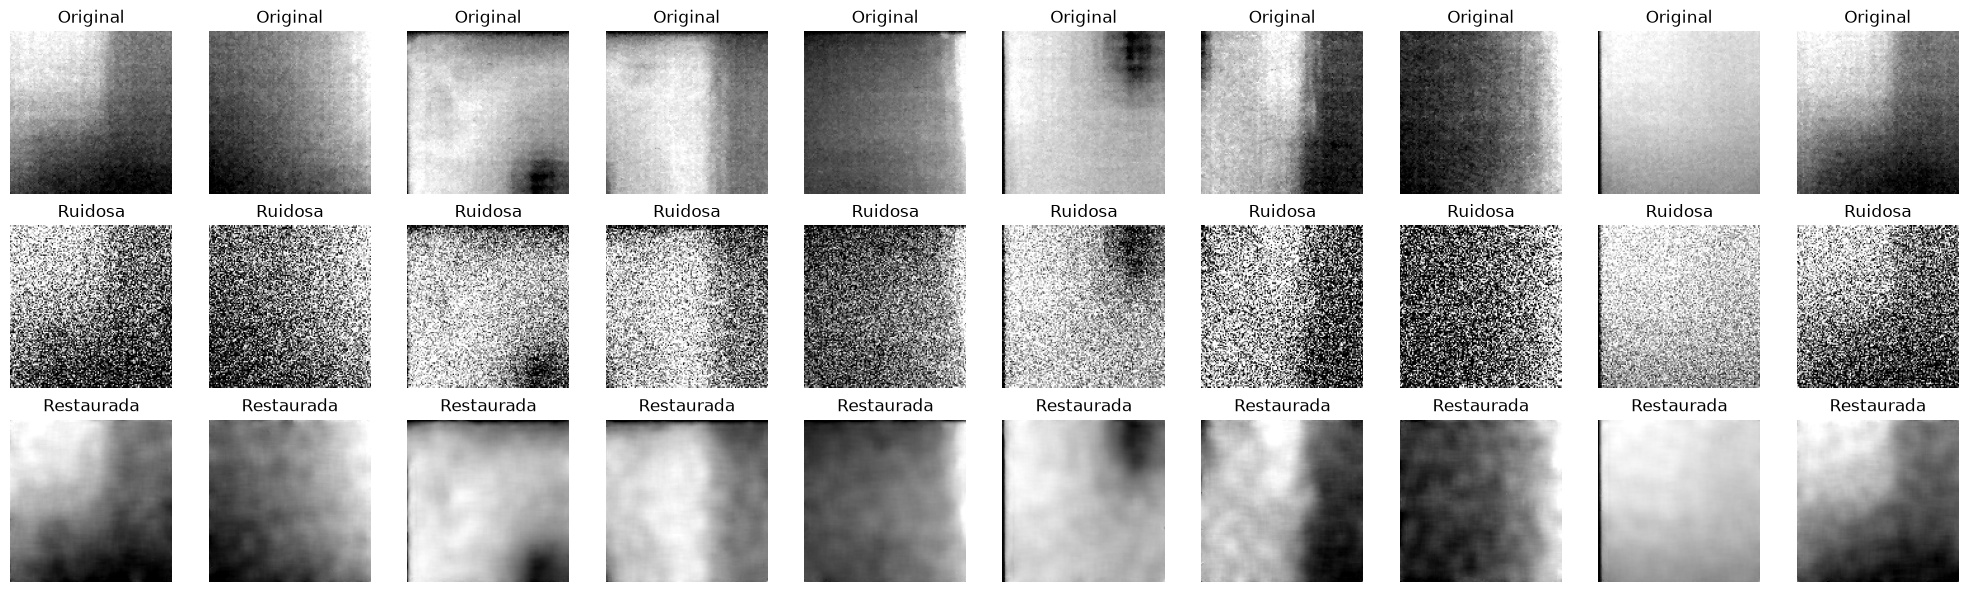

In [31]:
n = 10

plt.figure(figsize=(20, 6))

for i in range(n):
    idx = i + 43

    original = np.squeeze(x_test[idx])
    noisy = np.squeeze(x_test_noisy[idx])
    denoised = np.squeeze(decoded_imgs[idx])

    # Janela de visualização definida pela imagem original
    vmin = np.percentile(original, 1)
    vmax = np.percentile(original, 99)

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(
        original,
        cmap='gray',
        vmin=vmin,
        vmax=vmax
    )
    plt.title('Original')
    ax.axis('off')

    # Ruidosa
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(
        noisy,
        cmap='gray',
        vmin=vmin,
        vmax=vmax
    )
    plt.title('Ruidosa')
    ax.axis('off')

    # Restaurada
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(
        denoised,
        cmap='gray',
        vmin=vmin,
        vmax=vmax
    )
    plt.title('Restaurada')
    ax.axis('off')

plt.tight_layout()
plt.show()